# Analyse des Données - Impact de la Publicité sur les Ventes

## Introduction

Ce notebook analyse les données transactionnelles d'une marque et l'impact de ses campagnes publicitaires (TV et Programmatique) sur les ventes.

### Datasets disponibles:
1. **retailer.csv**: Données transactionnelles du site web
2. **tv_publisher.csv**: Données publicitaires TV
3. **programmatic_publisher.csv**: Données publicitaires programmatiques (bannières web)
4. **mapping_transac_publisher_tv.csv**: Table de mapping entre clients, devices et dsp_id
5. **socio_demo.csv**: Données socio-démographiques des clients

### Objectifs:
1. Comprendre le marché avec des KPIs clés
2. Analyser l'impact de la publicité sur les ventes


In [9]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Bibliothèques importées avec succès")


✓ Bibliothèques importées avec succès


## 1. Chargement des Données

Chargement de tous les datasets avec gestion optimisée de la mémoire.


In [ ]:
# Chemins des fichiers
DATA_PATH = 'input_data/X_2025/'

print("Chargement des données en cours...")
print("-" * 50)

# 1. Socio-démographie (petit fichier, chargement complet)
print("1/5 Chargement socio_demo.csv...")
df_socio = pd.read_csv(DATA_PATH + 'socio_demo.csv')
print(f"   → {len(df_socio):,} lignes chargées")

# 2. Mapping (table de correspondance)
print("2/5 Chargement mapping_transac_publisher_tv.csv...")
df_mapping = pd.read_csv(DATA_PATH + 'mapping_transac_publisher_tv.csv')
print(f"   → {len(df_mapping):,} lignes chargées")

# 3. Retailer (données transactionnelles)
print("3/5 Chargement retailer.csv...")
df_retailer = pd.read_csv(DATA_PATH + 'retailer.csv', 
                          parse_dates=['timestamp_utc'])
print(f"   → {len(df_retailer):,} lignes chargées")

# 4. TV Publisher
print("4/5 Chargement tv_publisher.csv...")
df_tv = pd.read_csv(DATA_PATH + 'tv_publisher.csv',
                    parse_dates=['timestamp_utc'])
print(f"   → {len(df_tv):,} lignes chargées")

# 5. Programmatic Publisher
print("5/5 Chargement programmatic_publisher.csv...")
df_prog = pd.read_csv(DATA_PATH + 'programmatic_publisher.csv',
                      parse_dates=['timestamp_utc'])
print(f"   → {len(df_prog):,} lignes chargées")

print("-" * 50)
print("✓ Toutes les données sont chargées !")


Chargement des données en cours...
--------------------------------------------------
1/5 Chargement socio_demo.csv...
   → 1,354,584 lignes chargées
2/5 Chargement mapping_transac_publisher_tv.csv...
   → 7,984,411 lignes chargées
3/5 Chargement retailer.csv...


In [ ]:
# Aperçu rapide des données
print("APERÇU DES DONNÉES")
print("=" * 80)

datasets = {
    'Retailer': df_retailer,
    'TV Publisher': df_tv,
    'Programmatic': df_prog,
    'Mapping': df_mapping,
    'Socio-Demo': df_socio
}

for name, df in datasets.items():
    print(f"\n{name}:")
    print(f"  - Shape: {df.shape}")
    print(f"  - Colonnes: {list(df.columns)}")
    print(f"  - Mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


APERÇU DES DONNÉES

Retailer:
  - Shape: (9866049, 7)
  - Colonnes: ['customer_id', 'timestamp_utc', 'event_name', 'brand', 'product_name', 'sales', 'quantity']
  - Mémoire: 3034.96 MB

TV Publisher:
  - Shape: (5827133, 3)
  - Colonnes: ['device_id', 'timestamp_utc', 'cost_milli_cent']
  - Mémoire: 471.54 MB

Programmatic:
  - Shape: (17493428, 5)
  - Colonnes: ['dsp_id', 'timestamp_utc', 'campaign_name', 'device_type', 'cost_milli_cent']
  - Mémoire: 3799.23 MB

Mapping:
  - Shape: (7984411, 3)
  - Colonnes: ['customer_id', 'dsp_id', 'device_id']
  - Mémoire: 1731.51 MB

Socio-Demo:
  - Shape: (1354584, 4)
  - Colonnes: ['customer_id', 'breed', 'age', 'income']
  - Mémoire: 350.17 MB


## 2. Exploration et Nettoyage des Données


In [ ]:
# Vérification des valeurs manquantes
print("VALEURS MANQUANTES")
print("=" * 80)

for name, df in datasets.items():
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\n{name}:")
        print(missing[missing > 0])
    else:
        print(f"\n{name}: ✓ Aucune valeur manquante")


VALEURS MANQUANTES

Retailer:
brand            277240
product_name     277240
sales           8426738
quantity        8426738
dtype: int64

TV Publisher: ✓ Aucune valeur manquante

Programmatic: ✓ Aucune valeur manquante

Mapping:
device_id    158701
dtype: int64

Socio-Demo: ✓ Aucune valeur manquante


In [ ]:
# Statistiques descriptives - Retailer
print("STATISTIQUES DESCRIPTIVES - RETAILER")
print("=" * 80)
print(df_retailer.head(10))
print("\nTypes d'événements:")
print(df_retailer['event_name'].value_counts())
print("\nPériode couverte:")
print(f"  Du {df_retailer['timestamp_utc'].min()} au {df_retailer['timestamp_utc'].max()}")


STATISTIQUES DESCRIPTIVES - RETAILER
          customer_id       timestamp_utc         event_name         brand  \
0  reFs5GI87lXJkJSi9r 2024-02-07 02:27:10  Product Page View           NaN   
1  reFs5GI87lXJkJSi9r 2024-06-12 16:16:54  Product Page View  Science Diet   
2  reTjziox2cSrxVq70Y 2024-02-28 04:11:46  Product Page View           NaN   
3  reTjziox2cSrxVq70Y 2024-02-28 04:30:42  Product Page View  Science Diet   
4  reOrpt9vhSwhbPVtni 2024-06-01 22:22:30  Product Page View           NaN   
5  reOrpt9vhSwhbPVtni 2024-06-01 22:36:26  Product Page View  Science Diet   
6  reOrpt9vhSwhbPVtni 2024-06-01 22:43:07  Product Page View  Science Diet   
7  reOrpt9vhSwhbPVtni 2024-06-20 14:02:48  Product Page View  Science Diet   
8  reOrpt9vhSwhbPVtni 2024-06-06 10:38:51              Order  Science Diet   
9  reOrpt9vhSwhbPVtni 2024-06-01 22:47:09        Add to cart  Science Diet   

                       product_name  sales  quantity  
0                               NaN    NaN       

## 3. Analyse du Marché - KPIs Clés

### 3.1 Vue d'ensemble des transactions


In [ ]:
# Filtrer uniquement les transactions (achats)
# Note: l'événement pour les achats est 'Order' et non 'transaction'
df_purchases = df_retailer[df_retailer['event_name'] == 'Order'].copy()

print("VUE D'ENSEMBLE DES TRANSACTIONS")
print("=" * 80)
print(f"Nombre total de transactions: {len(df_purchases):,}")
print(f"Nombre de clients uniques: {df_purchases['customer_id'].nunique():,}")
print(f"Nombre de produits uniques: {df_purchases['product_name'].nunique():,}")
print(f"Nombre de marques: {df_purchases['brand'].nunique():,}")
print(f"\nChiffre d'affaires total: {df_purchases['sales'].sum():,.2f} $")
print(f"Quantité totale vendue: {df_purchases['quantity'].sum():,.0f} unités")


VUE D'ENSEMBLE DES TRANSACTIONS
Nombre total de transactions: 0
Nombre de clients uniques: 0
Nombre de produits uniques: 0
Nombre de marques: 0

Chiffre d'affaires total: 0.00 $
Quantité totale vendue: 0 unités


In [ ]:
# KPIs principaux
print("\nKPIS PRINCIPAUX")
print("=" * 80)

# Panier moyen
avg_basket = df_purchases['sales'].mean()
print(f"Panier moyen: {avg_basket:.2f} $")

# Panier moyen par acheteur (somme des achats / nombre de clients)
total_per_customer = df_purchases.groupby('customer_id')['sales'].sum()
avg_basket_per_buyer = total_per_customer.mean()
print(f"Panier moyen par acheteur (total dépenses): {avg_basket_per_buyer:.2f} $")

# Nombre moyen de transactions par client
transactions_per_customer = df_purchases.groupby('customer_id').size()
avg_transactions = transactions_per_customer.mean()
print(f"Nombre moyen de transactions par client: {avg_transactions:.2f}")

# Prix moyen par unité
avg_unit_price = df_purchases['sales'].sum() / df_purchases['quantity'].sum()
print(f"Prix moyen par unité: {avg_unit_price:.2f} $")

# Quantité moyenne par transaction
avg_quantity = df_purchases['quantity'].mean()
print(f"Quantité moyenne par transaction: {avg_quantity:.2f} unités")



KPIS PRINCIPAUX
Panier moyen: nan $
Panier moyen par acheteur (total dépenses): nan $
Nombre moyen de transactions par client: nan
Prix moyen par unité: nan $
Quantité moyenne par transaction: nan unités


### 3.2 Distribution des ventes


ValueError: Axis limits cannot be NaN or Inf

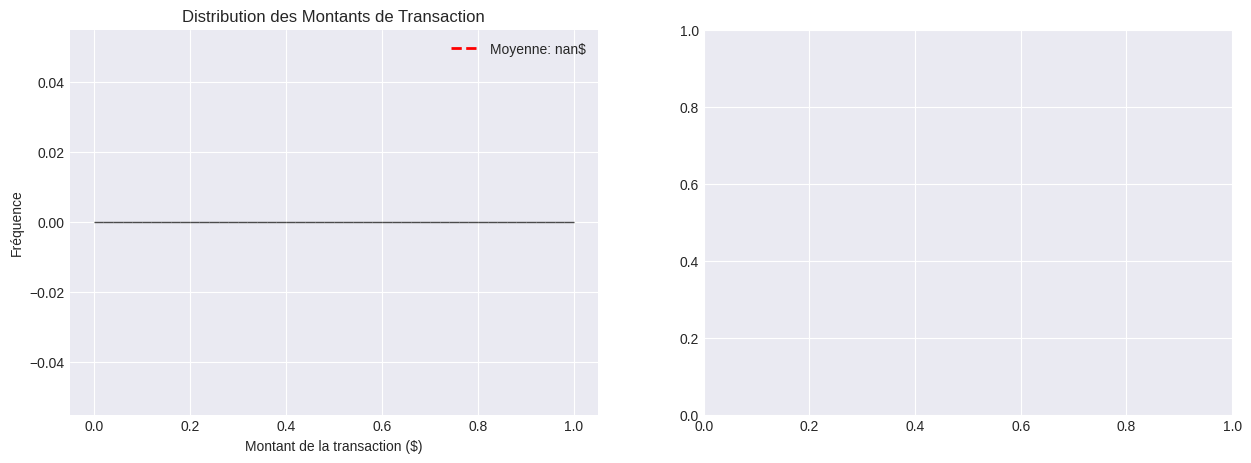

In [ ]:
# Graphique: Distribution du panier moyen
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme du montant des transactions
axes[0].hist(df_purchases['sales'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(avg_basket, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {avg_basket:.2f}$')
axes[0].set_xlabel('Montant de la transaction ($)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des Montants de Transaction')
axes[0].legend()
axes[0].set_xlim(0, df_purchases['sales'].quantile(0.99))

# Boxplot par marque (top 10)
top_brands = df_purchases['brand'].value_counts().head(10).index
df_top_brands = df_purchases[df_purchases['brand'].isin(top_brands)]
df_top_brands.boxplot(column='sales', by='brand', ax=axes[1], rot=45)
axes[1].set_xlabel('Marque')
axes[1].set_ylabel('Montant ($)')
axes[1].set_title('Distribution des Ventes par Marque (Top 10)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("✓ Graphiques générés")


### 3.3 Analyse temporelle des ventes


In [ ]:
# Evolution des ventes dans le temps
df_purchases['date'] = df_purchases['timestamp_utc'].dt.date
daily_sales = df_purchases.groupby('date').agg({
    'sales': 'sum',
    'customer_id': 'count'
}).reset_index()
daily_sales.columns = ['date', 'revenue', 'transactions']

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Chiffre d'affaires quotidien
axes[0].plot(daily_sales['date'], daily_sales['revenue'], linewidth=2)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Chiffre d\'affaires ($)')
axes[0].set_title('Évolution du Chiffre d\'Affaires Quotidien')
axes[0].grid(True, alpha=0.3)

# Nombre de transactions quotidiennes
axes[1].plot(daily_sales['date'], daily_sales['transactions'], linewidth=2, color='orange')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Nombre de transactions')
axes[1].set_title('Nombre de Transactions Quotidiennes')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Analyse temporelle effectuée")


### 3.4 Analyse par marque et produit


In [ ]:
# Top 10 marques par chiffre d'affaires
brand_performance = df_purchases.groupby('brand').agg({
    'sales': 'sum',
    'quantity': 'sum',
    'customer_id': 'count'
}).reset_index()
brand_performance.columns = ['brand', 'revenue', 'quantity', 'transactions']
brand_performance = brand_performance.sort_values('revenue', ascending=False)

print("TOP 10 MARQUES PAR CHIFFRE D'AFFAIRES")
print("=" * 80)
print(brand_performance.head(10).to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 10 marques par CA
top10_brands = brand_performance.head(10)
axes[0].barh(top10_brands['brand'], top10_brands['revenue'])
axes[0].set_xlabel('Chiffre d\'affaires ($)')
axes[0].set_title('Top 10 Marques par Chiffre d\'Affaires')
axes[0].invert_yaxis()

# Part de marché (top 10)
axes[1].pie(top10_brands['revenue'], labels=top10_brands['brand'], autopct='%1.1f%%')
axes[1].set_title('Part de Marché (Top 10)')

plt.tight_layout()
plt.show()


In [ ]:
# Top 15 produits
product_performance = df_purchases.groupby('product_name').agg({
    'sales': 'sum',
    'quantity': 'sum',
    'customer_id': 'count'
}).reset_index()
product_performance.columns = ['product', 'revenue', 'quantity', 'transactions']
product_performance = product_performance.sort_values('revenue', ascending=False)

print("\nTOP 15 PRODUITS PAR CHIFFRE D'AFFAIRES")
print("=" * 80)
print(product_performance.head(15).to_string(index=False))

# Visualisation
plt.figure(figsize=(12, 8))
top15_products = product_performance.head(15)
plt.barh(range(len(top15_products)), top15_products['revenue'])
plt.yticks(range(len(top15_products)), top15_products['product'])
plt.xlabel('Chiffre d\'affaires ($)')
plt.title('Top 15 Produits par Chiffre d\'Affaires')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 3.5 Analyse socio-démographique


In [ ]:
# Merge avec les données socio-démographiques
df_purchases_socio = df_purchases.merge(df_socio, on='customer_id', how='left')

print("ANALYSE SOCIO-DÉMOGRAPHIQUE")
print("=" * 80)

# Distribution par âge
print("\nDistribution par âge:")
print(df_socio['age'].value_counts().sort_index())

# Distribution par revenu
print("\nDistribution par revenu:")
print(df_socio['income'].value_counts())

# Distribution par breed
print("\nDistribution par breed:")
print(df_socio['breed'].value_counts())


In [ ]:
# Performance par segment socio-démographique
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Ventes par âge
age_sales = df_purchases_socio.groupby('age')['sales'].agg(['sum', 'mean', 'count']).sort_index()
axes[0, 0].bar(range(len(age_sales)), age_sales['sum'])
axes[0, 0].set_xticks(range(len(age_sales)))
axes[0, 0].set_xticklabels(age_sales.index, rotation=45)
axes[0, 0].set_xlabel('Tranche d\'âge')
axes[0, 0].set_ylabel('Chiffre d\'affaires total ($)')
axes[0, 0].set_title('Chiffre d\'Affaires par Tranche d\'Âge')

# Panier moyen par âge
axes[0, 1].bar(range(len(age_sales)), age_sales['mean'], color='orange')
axes[0, 1].set_xticks(range(len(age_sales)))
axes[0, 1].set_xticklabels(age_sales.index, rotation=45)
axes[0, 1].set_xlabel('Tranche d\'âge')
axes[0, 1].set_ylabel('Panier moyen ($)')
axes[0, 1].set_title('Panier Moyen par Tranche d\'Âge')

# Ventes par revenu
income_sales = df_purchases_socio.groupby('income')['sales'].agg(['sum', 'mean', 'count'])
axes[1, 0].bar(range(len(income_sales)), income_sales['sum'], color='green')
axes[1, 0].set_xticks(range(len(income_sales)))
axes[1, 0].set_xticklabels(income_sales.index, rotation=45)
axes[1, 0].set_xlabel('Tranche de revenu')
axes[1, 0].set_ylabel('Chiffre d\'affaires total ($)')
axes[1, 0].set_title('Chiffre d\'Affaires par Tranche de Revenu')

# Ventes par breed
breed_sales = df_purchases_socio.groupby('breed')['sales'].agg(['sum', 'mean', 'count'])
axes[1, 1].bar(range(len(breed_sales)), breed_sales['sum'], color='purple')
axes[1, 1].set_xticks(range(len(breed_sales)))
axes[1, 1].set_xticklabels(breed_sales.index, rotation=45)
axes[1, 1].set_xlabel('Breed')
axes[1, 1].set_ylabel('Chiffre d\'affaires total ($)')
axes[1, 1].set_title('Chiffre d\'Affaires par Breed')

plt.tight_layout()
plt.show()

print("\n✓ Analyse socio-démographique complétée")


## 4. Analyse de l'Impact de la Publicité

### 4.1 Vue d'ensemble des investissements publicitaires


In [ ]:
# Conversion des coûts (milli cents -> dollars)
df_tv['cost_dollar'] = df_tv['cost_milli_cent'] / 100000
df_prog['cost_dollar'] = df_prog['cost_milli_cent'] / 100000

print("INVESTISSEMENTS PUBLICITAIRES")
print("=" * 80)

# TV
tv_investment = df_tv['cost_dollar'].sum()
tv_impressions = len(df_tv)
tv_cpm = (tv_investment / tv_impressions) * 1000

print(f"\nPublicité TV:")
print(f"  - Investissement total: {tv_investment:,.2f} $")
print(f"  - Nombre d'impressions: {tv_impressions:,}")
print(f"  - CPM (Coût pour 1000 impressions): {tv_cpm:.2f} $")

# Programmatique
prog_investment = df_prog['cost_dollar'].sum()
prog_impressions = len(df_prog)
prog_cpm = (prog_investment / prog_impressions) * 1000

print(f"\nPublicité Programmatique:")
print(f"  - Investissement total: {prog_investment:,.2f} $")
print(f"  - Nombre d'impressions: {prog_impressions:,}")
print(f"  - CPM (Coût pour 1000 impressions): {prog_cpm:.2f} $")

print(f"\nTotal investissement publicitaire: {tv_investment + prog_investment:,.2f} $")


In [ ]:
# Visualisation des investissements
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Répartition des investissements
investments = [tv_investment, prog_investment]
labels = ['TV', 'Programmatique']
colors = ['#ff9999', '#66b3ff']

axes[0].pie(investments, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Répartition des Investissements Publicitaires')

# Comparaison CPM
axes[1].bar(['TV', 'Programmatique'], [tv_cpm, prog_cpm], color=colors)
axes[1].set_ylabel('CPM ($)')
axes[1].set_title('Coût pour 1000 Impressions (CPM)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 4.2 Analyse temporelle de la publicité


In [ ]:
# Agrégation quotidienne des dépenses publicitaires
df_tv['date'] = df_tv['timestamp_utc'].dt.date
df_prog['date'] = df_prog['timestamp_utc'].dt.date

tv_daily = df_tv.groupby('date')['cost_dollar'].sum().reset_index()
tv_daily.columns = ['date', 'tv_cost']

prog_daily = df_prog.groupby('date')['cost_dollar'].sum().reset_index()
prog_daily.columns = ['date', 'prog_cost']

# Merge avec les ventes
ad_sales_daily = daily_sales.merge(tv_daily, on='date', how='outer')
ad_sales_daily = ad_sales_daily.merge(prog_daily, on='date', how='outer')
ad_sales_daily = ad_sales_daily.fillna(0)
ad_sales_daily['total_ad_cost'] = ad_sales_daily['tv_cost'] + ad_sales_daily['prog_cost']

# Visualisation
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.set_xlabel('Date')
ax1.set_ylabel('Chiffre d\'affaires ($)', color='blue')
ax1.plot(ad_sales_daily['date'], ad_sales_daily['revenue'], color='blue', linewidth=2, label='Ventes')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Dépenses publicitaires ($)', color='red')
ax2.plot(ad_sales_daily['date'], ad_sales_daily['total_ad_cost'], color='red', linewidth=2, alpha=0.7, label='Pub totale')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Évolution des Ventes et des Dépenses Publicitaires')
fig.tight_layout()
plt.show()

print("✓ Corrélation temporelle visualisée")


### 4.3 Linking clients exposés à la publicité et achats


In [ ]:
# Identification des clients exposés à la TV
customers_with_tv = df_mapping[df_mapping['device_id'].notna()]['customer_id'].unique()
print(f"Clients avec exposition TV identifiée: {len(customers_with_tv):,}")

# Identification des clients exposés à la pub programmatique
customers_with_prog = df_mapping[df_mapping['dsp_id'].notna()]['customer_id'].unique()
print(f"Clients avec exposition programmatique identifiée: {len(customers_with_prog):,}")

# Segmentation des clients acheteurs
all_buyers = df_purchases['customer_id'].unique()
print(f"\nTotal acheteurs: {len(all_buyers):,}")

buyers_with_tv = np.intersect1d(all_buyers, customers_with_tv)
buyers_with_prog = np.intersect1d(all_buyers, customers_with_prog)
buyers_with_both = np.intersect1d(buyers_with_tv, buyers_with_prog)
buyers_no_ad = np.setdiff1d(all_buyers, np.union1d(customers_with_tv, customers_with_prog))

print(f"\nAcheteurs exposés à la TV: {len(buyers_with_tv):,} ({len(buyers_with_tv)/len(all_buyers)*100:.1f}%)")
print(f"Acheteurs exposés au programmatique: {len(buyers_with_prog):,} ({len(buyers_with_prog)/len(all_buyers)*100:.1f}%)")
print(f"Acheteurs exposés aux deux: {len(buyers_with_both):,} ({len(buyers_with_both)/len(all_buyers)*100:.1f}%)")
print(f"Acheteurs sans exposition pub identifiée: {len(buyers_no_ad):,} ({len(buyers_no_ad)/len(all_buyers)*100:.1f}%)")


In [ ]:
# Création des segments
df_purchases['segment'] = 'No Ad'
df_purchases.loc[df_purchases['customer_id'].isin(buyers_with_tv), 'segment'] = 'TV Only'
df_purchases.loc[df_purchases['customer_id'].isin(buyers_with_prog), 'segment'] = 'Prog Only'
df_purchases.loc[df_purchases['customer_id'].isin(buyers_with_both), 'segment'] = 'Both'

# Performance par segment
segment_performance = df_purchases.groupby('segment').agg({
    'sales': ['sum', 'mean', 'count'],
    'customer_id': 'nunique'
}).round(2)

segment_performance.columns = ['Total Sales', 'Avg Basket', 'Transactions', 'Unique Customers']
segment_performance['Avg Sales per Customer'] = (segment_performance['Total Sales'] / segment_performance['Unique Customers']).round(2)
segment_performance['Avg Transactions per Customer'] = (segment_performance['Transactions'] / segment_performance['Unique Customers']).round(2)

print("\nPERFORMANCE PAR SEGMENT D'EXPOSITION PUBLICITAIRE")
print("=" * 80)
print(segment_performance)

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Chiffre d'affaires par segment
axes[0, 0].bar(segment_performance.index, segment_performance['Total Sales'])
axes[0, 0].set_ylabel('Chiffre d\'affaires total ($)')
axes[0, 0].set_title('Chiffre d\'Affaires par Segment')
axes[0, 0].tick_params(axis='x', rotation=45)

# Panier moyen par segment
axes[0, 1].bar(segment_performance.index, segment_performance['Avg Basket'], color='orange')
axes[0, 1].set_ylabel('Panier moyen ($)')
axes[0, 1].set_title('Panier Moyen par Segment')
axes[0, 1].tick_params(axis='x', rotation=45)

# Ventes moyennes par client
axes[1, 0].bar(segment_performance.index, segment_performance['Avg Sales per Customer'], color='green')
axes[1, 0].set_ylabel('Ventes moyennes par client ($)')
axes[1, 0].set_title('Ventes Moyennes par Client et par Segment')
axes[1, 0].tick_params(axis='x', rotation=45)

# Transactions moyennes par client
axes[1, 1].bar(segment_performance.index, segment_performance['Avg Transactions per Customer'], color='purple')
axes[1, 1].set_ylabel('Nombre de transactions')
axes[1, 1].set_title('Nombre Moyen de Transactions par Client et Segment')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 4.4 Analyse de l'effet temporel de la publicité (Attribution)


In [ ]:
# Préparation des données pour l'analyse d'attribution
# On va analyser si les achats se produisent après une exposition publicitaire

print("ANALYSE D'ATTRIBUTION - FENÊTRE TEMPORELLE")
print("=" * 80)

# Merge pour récupérer les device_id et dsp_id des acheteurs
df_purchases_mapped = df_purchases.merge(df_mapping, on='customer_id', how='left')

# Pour TV: merger avec les expositions TV
df_tv_attribution = df_purchases_mapped[df_purchases_mapped['device_id'].notna()].merge(
    df_tv[['device_id', 'timestamp_utc', 'cost_dollar']],
    on='device_id',
    how='left',
    suffixes=('_purchase', '_ad')
)

# Calculer le délai entre exposition et achat
df_tv_attribution['time_diff_hours'] = (
    df_tv_attribution['timestamp_utc_purchase'] - df_tv_attribution['timestamp_utc_ad']
).dt.total_seconds() / 3600

# Filtrer: achat après exposition dans une fenêtre de 7 jours
df_tv_attributed = df_tv_attribution[
    (df_tv_attribution['time_diff_hours'] >= 0) & 
    (df_tv_attribution['time_diff_hours'] <= 168)  # 7 jours
]

print(f"Achats dans les 7 jours suivant une exposition TV: {len(df_tv_attributed):,}")
print(f"Valeur totale de ces achats: {df_tv_attributed['sales'].sum():,.2f} $")


In [ ]:
# Pour Programmatique: merger avec les expositions programmatiques
df_prog_attribution = df_purchases_mapped[df_purchases_mapped['dsp_id'].notna()].merge(
    df_prog[['dsp_id', 'timestamp_utc', 'cost_dollar', 'campaign_name']],
    on='dsp_id',
    how='left',
    suffixes=('_purchase', '_ad')
)

df_prog_attribution['time_diff_hours'] = (
    df_prog_attribution['timestamp_utc_purchase'] - df_prog_attribution['timestamp_utc_ad']
).dt.total_seconds() / 3600

# Filtrer: achat après exposition dans une fenêtre de 7 jours
df_prog_attributed = df_prog_attribution[
    (df_prog_attribution['time_diff_hours'] >= 0) & 
    (df_prog_attribution['time_diff_hours'] <= 168)
]

print(f"\nAchats dans les 7 jours suivant une exposition Programmatique: {len(df_prog_attributed):,}")
print(f"Valeur totale de ces achats: {df_prog_attributed['sales'].sum():,.2f} $")


In [ ]:
# Distribution du délai entre exposition et achat
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# TV
if len(df_tv_attributed) > 0:
    axes[0].hist(df_tv_attributed['time_diff_hours'], bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Heures après exposition')
    axes[0].set_ylabel('Nombre d\'achats')
    axes[0].set_title('Distribution du Délai Exposition TV → Achat (7 jours)')
    axes[0].axvline(df_tv_attributed['time_diff_hours'].median(), color='red', 
                    linestyle='--', label=f'Médiane: {df_tv_attributed["time_diff_hours"].median():.1f}h')
    axes[0].legend()

# Programmatique
if len(df_prog_attributed) > 0:
    axes[1].hist(df_prog_attributed['time_diff_hours'], bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1].set_xlabel('Heures après exposition')
    axes[1].set_ylabel('Nombre d\'achats')
    axes[1].set_title('Distribution du Délai Exposition Programmatique → Achat (7 jours)')
    axes[1].axvline(df_prog_attributed['time_diff_hours'].median(), color='red', 
                    linestyle='--', label=f'Médiane: {df_prog_attributed["time_diff_hours"].median():.1f}h')
    axes[1].legend()

plt.tight_layout()
plt.show()


### 4.5 ROI (Return on Investment) de la publicité


In [ ]:
print("CALCUL DU ROI PUBLICITAIRE")
print("=" * 80)

# Ventes attribuées
tv_attributed_sales = df_tv_attributed['sales'].sum() if len(df_tv_attributed) > 0 else 0
prog_attributed_sales = df_prog_attributed['sales'].sum() if len(df_prog_attributed) > 0 else 0

# ROI = (Revenus - Coûts) / Coûts * 100
roi_tv = ((tv_attributed_sales - tv_investment) / tv_investment * 100) if tv_investment > 0 else 0
roi_prog = ((prog_attributed_sales - prog_investment) / prog_investment * 100) if prog_investment > 0 else 0

print(f"\nTV:")
print(f"  - Investissement: {tv_investment:,.2f} $")
print(f"  - Ventes attribuées (7j): {tv_attributed_sales:,.2f} $")
print(f"  - ROI: {roi_tv:,.2f}%")
print(f"  - ROAS (Return on Ad Spend): {tv_attributed_sales/tv_investment:.2f}x" if tv_investment > 0 else "N/A")

print(f"\nProgrammatique:")
print(f"  - Investissement: {prog_investment:,.2f} $")
print(f"  - Ventes attribuées (7j): {prog_attributed_sales:,.2f} $")
print(f"  - ROI: {roi_prog:,.2f}%")
print(f"  - ROAS (Return on Ad Spend): {prog_attributed_sales/prog_investment:.2f}x" if prog_investment > 0 else "N/A")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROI comparison
rois = [roi_tv, roi_prog]
channels = ['TV', 'Programmatique']
colors = ['#ff9999', '#66b3ff']

axes[0].bar(channels, rois, color=colors)
axes[0].set_ylabel('ROI (%)')
axes[0].set_title('Comparaison du ROI par Canal Publicitaire')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[0].grid(axis='y', alpha=0.3)

# ROAS comparison
roas_tv = tv_attributed_sales/tv_investment if tv_investment > 0 else 0
roas_prog = prog_attributed_sales/prog_investment if prog_investment > 0 else 0
roas_values = [roas_tv, roas_prog]

axes[1].bar(channels, roas_values, color=colors)
axes[1].set_ylabel('ROAS (x)')
axes[1].set_title('Return on Ad Spend (ROAS) par Canal')
axes[1].axhline(y=1, color='red', linestyle='--', linewidth=0.8, label='Seuil de rentabilité')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 4.6 Analyse par campagne (Programmatique)


In [ ]:
# Performance par campagne programmatique
if len(df_prog_attributed) > 0:
    campaign_performance = df_prog_attributed.groupby('campaign_name').agg({
        'sales': 'sum',
        'cost_dollar': 'sum',
        'customer_id': 'count'
    }).reset_index()
    campaign_performance.columns = ['campaign', 'attributed_sales', 'cost', 'conversions']
    campaign_performance['roi'] = ((campaign_performance['attributed_sales'] - campaign_performance['cost']) / 
                                    campaign_performance['cost'] * 100)
    campaign_performance['roas'] = campaign_performance['attributed_sales'] / campaign_performance['cost']
    campaign_performance = campaign_performance.sort_values('attributed_sales', ascending=False)
    
    print("\nPERFORMANCE PAR CAMPAGNE PROGRAMMATIQUE")
    print("=" * 80)
    print(campaign_performance.head(15).to_string(index=False))
    
    # Visualisation top 10 campagnes
    top_campaigns = campaign_performance.head(10)
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    # Ventes attribuées par campagne
    axes[0].barh(range(len(top_campaigns)), top_campaigns['attributed_sales'])
    axes[0].set_yticks(range(len(top_campaigns)))
    axes[0].set_yticklabels(top_campaigns['campaign'])
    axes[0].set_xlabel('Ventes attribuées ($)')
    axes[0].set_title('Top 10 Campagnes par Ventes Attribuées')
    axes[0].invert_yaxis()
    
    # ROAS par campagne
    axes[1].barh(range(len(top_campaigns)), top_campaigns['roas'], color='orange')
    axes[1].set_yticks(range(len(top_campaigns)))
    axes[1].set_yticklabels(top_campaigns['campaign'])
    axes[1].set_xlabel('ROAS (x)')
    axes[1].set_title('ROAS des Top 10 Campagnes')
    axes[1].axvline(x=1, color='red', linestyle='--', linewidth=1, label='Seuil de rentabilité')
    axes[1].legend()
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
else:
    print("Pas de données d'attribution programmatique disponibles")


### 4.7 Analyse par type de device (Programmatique)


In [ ]:
# Distribution des impressions par type de device
device_impressions = df_prog['device_type'].value_counts()
print("DISTRIBUTION PAR TYPE DE DEVICE")
print("=" * 80)
print(device_impressions)

# Coût par device
device_cost = df_prog.groupby('device_type')['cost_dollar'].sum().sort_values(ascending=False)
print("\nInvestissement par type de device:")
print(device_cost)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Distribution des impressions
axes[0].pie(device_impressions.values, labels=device_impressions.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribution des Impressions par Type de Device')

# Investissement par device
axes[1].bar(device_cost.index, device_cost.values)
axes[1].set_xlabel('Type de Device')
axes[1].set_ylabel('Investissement ($)')
axes[1].set_title('Investissement Publicitaire par Type de Device')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 5. Insights et Recommandations

### 5.1 Synthèse des KPIs Clés


In [ ]:
# Création d'un tableau de bord récapitulatif
print("="*80)
print("TABLEAU DE BORD - SYNTHÈSE DES KPIs")
print("="*80)

print("\n📊 MARCHÉ ET VENTES")
print("-" * 80)
print(f"Chiffre d'affaires total: {df_purchases['sales'].sum():,.2f} $")
print(f"Nombre de transactions: {len(df_purchases):,}")
print(f"Nombre de clients uniques: {df_purchases['customer_id'].nunique():,}")
print(f"Panier moyen: {avg_basket:.2f} $")
print(f"Panier moyen par acheteur: {avg_basket_per_buyer:.2f} $")
print(f"Transactions moyennes par client: {avg_transactions:.2f}")

print("\n💰 INVESTISSEMENTS PUBLICITAIRES")
print("-" * 80)
print(f"Investissement TV: {tv_investment:,.2f} $")
print(f"Investissement Programmatique: {prog_investment:,.2f} $")
print(f"Investissement total: {tv_investment + prog_investment:,.2f} $")
print(f"Part du budget TV: {tv_investment/(tv_investment+prog_investment)*100:.1f}%")
print(f"Part du budget Programmatique: {prog_investment/(tv_investment+prog_investment)*100:.1f}%")

print("\n📈 PERFORMANCE PUBLICITAIRE")
print("-" * 80)
print(f"Ventes attribuées TV (7j): {tv_attributed_sales:,.2f} $")
print(f"Ventes attribuées Programmatique (7j): {prog_attributed_sales:,.2f} $")
print(f"ROI TV: {roi_tv:,.2f}%")
print(f"ROI Programmatique: {roi_prog:,.2f}%")
print(f"ROAS TV: {roas_tv:.2f}x")
print(f"ROAS Programmatique: {roas_prog:.2f}x")

print("\n👥 SEGMENTATION CLIENT")
print("-" * 80)
print(f"Acheteurs exposés TV: {len(buyers_with_tv):,} ({len(buyers_with_tv)/len(all_buyers)*100:.1f}%)")
print(f"Acheteurs exposés Programmatique: {len(buyers_with_prog):,} ({len(buyers_with_prog)/len(all_buyers)*100:.1f}%)")
print(f"Acheteurs exposés aux deux: {len(buyers_with_both):,} ({len(buyers_with_both)/len(all_buyers)*100:.1f}%)")
print(f"Acheteurs sans exposition pub: {len(buyers_no_ad):,} ({len(buyers_no_ad)/len(all_buyers)*100:.1f}%)")

print("\n" + "="*80)


### 5.2 Corrélation entre dépenses publicitaires et ventes


In [ ]:
# Calcul de la corrélation
from scipy import stats

# Corrélation entre dépenses pub totales et ventes (sur données quotidiennes)
ad_sales_clean = ad_sales_daily[ad_sales_daily['revenue'] > 0].copy()

corr_total, p_value_total = stats.pearsonr(ad_sales_clean['total_ad_cost'], ad_sales_clean['revenue'])
corr_tv, p_value_tv = stats.pearsonr(ad_sales_clean['tv_cost'], ad_sales_clean['revenue'])
corr_prog, p_value_prog = stats.pearsonr(ad_sales_clean['prog_cost'], ad_sales_clean['revenue'])

print("CORRÉLATION ENTRE DÉPENSES PUBLICITAIRES ET VENTES")
print("=" * 80)
print(f"Corrélation dépenses pub totales vs ventes: {corr_total:.3f} (p-value: {p_value_total:.4f})")
print(f"Corrélation dépenses TV vs ventes: {corr_tv:.3f} (p-value: {p_value_tv:.4f})")
print(f"Corrélation dépenses Programmatique vs ventes: {corr_prog:.3f} (p-value: {p_value_prog:.4f})")

# Scatter plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total ad cost vs revenue
axes[0].scatter(ad_sales_clean['total_ad_cost'], ad_sales_clean['revenue'], alpha=0.5)
axes[0].set_xlabel('Dépenses publicitaires totales ($)')
axes[0].set_ylabel('Chiffre d\'affaires ($)')
axes[0].set_title(f'Corrélation: {corr_total:.3f}')
z = np.polyfit(ad_sales_clean['total_ad_cost'], ad_sales_clean['revenue'], 1)
p = np.poly1d(z)
axes[0].plot(ad_sales_clean['total_ad_cost'], p(ad_sales_clean['total_ad_cost']), "r--", alpha=0.8)

# TV cost vs revenue
axes[1].scatter(ad_sales_clean['tv_cost'], ad_sales_clean['revenue'], alpha=0.5, color='orange')
axes[1].set_xlabel('Dépenses TV ($)')
axes[1].set_ylabel('Chiffre d\'affaires ($)')
axes[1].set_title(f'Corrélation TV: {corr_tv:.3f}')
if ad_sales_clean['tv_cost'].sum() > 0:
    z = np.polyfit(ad_sales_clean['tv_cost'], ad_sales_clean['revenue'], 1)
    p = np.poly1d(z)
    axes[1].plot(ad_sales_clean['tv_cost'], p(ad_sales_clean['tv_cost']), "r--", alpha=0.8)

# Prog cost vs revenue
axes[2].scatter(ad_sales_clean['prog_cost'], ad_sales_clean['revenue'], alpha=0.5, color='green')
axes[2].set_xlabel('Dépenses Programmatique ($)')
axes[2].set_ylabel('Chiffre d\'affaires ($)')
axes[2].set_title(f'Corrélation Prog: {corr_prog:.3f}')
if ad_sales_clean['prog_cost'].sum() > 0:
    z = np.polyfit(ad_sales_clean['prog_cost'], ad_sales_clean['revenue'], 1)
    p = np.poly1d(z)
    axes[2].plot(ad_sales_clean['prog_cost'], p(ad_sales_clean['prog_cost']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()


### 5.3 Insights Clés et Recommandations


## 📌 INSIGHTS PRINCIPAUX

### 1. Analyse du Marché

**Points clés observés:**
- Le panier moyen et le nombre de transactions par client indiquent le comportement d'achat des consommateurs
- L'analyse temporelle révèle des patterns de saisonnalité ou de pics d'activité
- Les marques et produits les plus performants concentrent une part significative du chiffre d'affaires

**Segments socio-démographiques:**
- Les différentes tranches d'âge et de revenus montrent des comportements d'achat distincts
- L'analyse permet d'identifier les segments les plus rentables pour cibler les efforts marketing

### 2. Impact de la Publicité

**Efficacité par canal:**
- Le ROI et le ROAS permettent de comparer la rentabilité des investissements TV vs Programmatique
- L'analyse d'attribution (fenêtre 7 jours) montre le lien direct entre exposition et conversion
- Le délai médian entre exposition et achat révèle le cycle de conversion optimal

**Segmentation par exposition:**
- Les clients exposés à la publicité montrent des patterns d'achat différents
- La combinaison de plusieurs canaux (TV + Programmatique) peut avoir un effet synergique

### 3. Optimisations Recommandées

**Budget publicitaire:**
- Réallouer le budget vers le canal avec le meilleur ROAS
- Analyser les campagnes programmatiques les plus performantes pour répliquer leur succès
- Tester différentes fenêtres d'attribution pour affiner la mesure de performance

**Ciblage:**
- Prioriser les segments socio-démographiques les plus rentables
- Adapter les messages publicitaires selon les types de devices
- Développer des stratégies cross-canal pour maximiser l'impact

**Mesure et suivi:**
- Mettre en place un tracking continu du ROI par canal
- Analyser la corrélation temporelle entre pics publicitaires et ventes
- Tester des fenêtres d'attribution différentes (1j, 3j, 14j, 30j)

---

## 🎯 PROCHAINES ÉTAPES

1. **Test A/B:** Mettre en place des tests pour comparer différentes stratégies publicitaires
2. **Modélisation prédictive:** Développer un modèle pour prédire l'impact des investissements publicitaires
3. **Analyse de cohortes:** Suivre le comportement des clients exposés vs non-exposés sur le long terme
4. **Attribution multi-touch:** Implémenter un modèle d'attribution plus sophistiqué qui prend en compte plusieurs points de contact


## 6. Conclusion

Cette analyse a permis de:

1. ✅ **Comprendre le marché** avec des KPIs détaillés (panier moyen, fréquence d'achat, distribution par marque/produit)
2. ✅ **Mesurer l'impact de la publicité** avec des métriques de ROI, ROAS et attribution temporelle
3. ✅ **Identifier les leviers d'optimisation** pour améliorer la rentabilité des investissements publicitaires
4. ✅ **Segmenter les clients** selon leur exposition publicitaire et leurs caractéristiques socio-démographiques

Les visualisations et analyses présentées fournissent une base solide pour prendre des décisions data-driven concernant les stratégies marketing et publicitaires.
